# πMPC live demo · ACC 2026

Three linear-MPC problems driven live by the public
[`PiMPC.jl`](https://github.com/SOLARIS-JHU/PiMPC.jl) v0.1.2 GPU/CPU ADMM solver.

| # | System | nx, nu | Task |
|---|---|---|---|
| 1 | **Cart-pole** | 4, 1 | balance an inverted pole, regulate cart to origin |
| 2 | **Tractor-trailer** | 5, 1 | articulated truck runs an ISO-3888 moose test |
| 3 | **Quadrotor (top-down)** | 8, 2 | 4-rotor tracks a figure-8 in the x–y plane |

Each demo builds a fresh `Model`, calls `setup!`, and runs a closed loop where
`solve!(model, x, u_prev, yref::Matrix(ny,Np), uref, w)` is invoked every step
with **per-stage** reference targets (matrix `yref`, added in `PiMPC v0.1.2`).


## 0 · Setup

In [1]:
using Pkg
# Self-contained: this notebook needs no local Project.toml. It uses a named
# *shared* environment so a single .ipynb dropped at any path just works.
# First run on a machine installs the pinned deps (needs internet); later runs
# are a fast no-op. Requires Julia 1.12 + the julia-1.12 IJulia kernel; the
# GPU demos need an NVIDIA GPU+CUDA, else PiMPC falls back to CPU.
Pkg.activate("pimpc_acc2026_demo"; shared=true)
Pkg.add([Pkg.PackageSpec(name="PiMPC", version=v"0.1.2"),
         Pkg.PackageSpec(name="CUDA"),
         Pkg.PackageSpec(name="Plots"),
         Pkg.PackageSpec(name="Statistics")])

using PiMPC, CUDA, LinearAlgebra, Statistics, Plots, Printf

# Shared palette — coherent look across all three demos.
const C_REF    = RGB(0.55, 0.57, 0.60)     # cool gray   – reference / target
const C_PATH   = RGB(0.78, 0.20, 0.18)     # carmine     – realised trajectory
const C_PRED   = RGB(0.18, 0.45, 0.71)     # steel blue  – MPC prediction
const C_BODY   = RGB(0.78, 0.20, 0.18)     # carmine     – primary body
const C_BODY2  = RGB(0.27, 0.32, 0.38)     # slate       – secondary body
const C_ARM    = RGB(0.18, 0.20, 0.24)     # near-black  – arms / outlines
const C_ROTOR  = RGB(0.78, 0.80, 0.82)     # light gray  – rotor disks
const C_CONE   = RGB(0.95, 0.60, 0.10)     # warm gold   – moose cones
const C_GROUND = RGB(0.30, 0.32, 0.36)

default(framestyle=:box, gridstyle=:dot, gridalpha=0.25, foreground_color_legend=nothing,
        background_color_legend=RGBA(1,1,1,0.85), legendfontsize=8)

println("CUDA: ", CUDA.functional() ? "✓ " * CUDA.name(CUDA.device()) : "✗")
println("PiMPC version: 0.1.2 (per-stage yref enabled)")

  Activating 

new project at `~/.julia/environments/pimpc_acc2026_demo`


    Updating registry at `~/.julia/registries/General.toml`


   Resolving 

package versions...


...


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (2))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


CUDA: ✓ NVIDIA GeForce RTX 3080


PiMPC version: 0.1.2 (per-stage yref enabled)


In [2]:
# Generic closed-loop driver — reused by demos 2 (trailer) and 3 (quadrotor).
function run_closed_loop(model, A_d, B_d, x0, yref_traj, uref, w, Nsim, Np)
    nx, nu = size(B_d)
    x_hist      = zeros(nx, Nsim+1)
    u_hist      = zeros(nu, Nsim)
    pred_hist   = zeros(nx, Np+1, Nsim)
    solve_times = zeros(Nsim)
    iter_hist   = zeros(Int, Nsim)
    x_hist[:, 1] .= x0
    u_prev = zeros(nu)
    for k in 1:Nsim
        yref_h = yref_traj[:, (k+1):(k+Np)]
        r = solve!(model, x_hist[:, k], u_prev, yref_h, uref, w)
        u_hist[:, k]      = r.u[:, 1]
        solve_times[k]    = r.info.solve_time
        iter_hist[k]      = r.info.iterations
        pred_hist[:, :, k] = r.x
        x_hist[:, k+1]    = A_d * x_hist[:, k] + B_d * u_hist[:, k]
        u_prev            = u_hist[:, k]
    end
    return x_hist, u_hist, pred_hist, solve_times, iter_hist
end

run_closed_loop (generic function with 1 method)

## 1 · Cart-pole · pre-stabilised regulation

Inverted pendulum on a cart (`[x, ẋ, θ, θ̇]`, input F). The open-loop pole is
**unstable**, so a vanilla ADMM-MPC is ill-conditioned and diverges. We apply
the textbook fix (Rawlings & Mayne): pre-stabilise with a discrete-LQR gain K
and let MPC optimise the residual command `v` with `u = v − Kx`. The realised
plant `x⁺ = (A−BK)x + Bv = A_cl x + B v` is **Schur-stable**, so ADMM
converges in a handful of iterations (CPU, sub-millisecond). Initial pole
tilt ≈ 17°; MPC drives pole upright + cart to origin and holds.

In [3]:
# Demo 1 · Cart-pole — pole-balancing regulation (pre-stabilised MPC)
#
# Inverted pendulum on a cart, linearised about the upright equilibrium:
#   States  x = [x_cart, ẋ_cart, θ, θ̇]   Input  u = F (cart force)
# The open-loop pole is unstable, which makes a vanilla ADMM-MPC ill-conditioned.
# Standard fix (Rawlings & Mayne §1.3): pre-stabilise with a discrete-LQR gain
# K, then let MPC optimise the residual command v with u = v − Kx.  The real
# plant under that law is x⁺ = (A−BK)x + Bv = A_cl x + B v, i.e. the MPC sees a
# Schur-stable prediction model — ADMM converges cleanly while MPC still does
# the constrained set-point regulation.
# ###########################################################################
println("\n=== Demo 1: Cart-pole regulation (pre-stabilised MPC) ===")

const M_c  = 1.0      # cart mass [kg]
const m_p  = 0.2      # pole mass [kg]
const l_p  = 0.5      # pole half-length [m]
const g_cp = 9.81

function cartpole_AB(Ts)
    A_c = [0.0  1.0   0.0                       0.0;
           0.0  0.0  -m_p*g_cp/M_c              0.0;
           0.0  0.0   0.0                       1.0;
           0.0  0.0   (M_c+m_p)*g_cp/(M_c*l_p)  0.0]
    B_c = reshape([0.0; 1.0/M_c; 0.0; -1.0/(M_c*l_p)], 4, 1)
    n = 4
    M = exp([A_c B_c; zeros(1, n+1)] .* Ts)
    return M[1:n, 1:n], M[1:n, n+1:end]
end

# Discrete-time LQR via the algebraic Riccati fixed-point iteration.
function dlqr(A, B, Q, R; iters=5000, tol=1e-12)
    P = copy(Q)
    for _ in 1:iters
        K  = (R .+ B'*P*B) \ (B'*P*A)
        Pn = Q + A'*P*A - A'*P*B*K
        maximum(abs.(Pn - P)) < tol && (P = Pn; break)
        P = Pn
    end
    return (R .+ B'*P*B) \ (B'*P*A)
end

Ts = 0.05
A_d, B_d = cartpole_AB(Ts)
C = [1.0 0.0 0.0 0.0; 0.0 0.0 1.0 0.0]    # output [x_cart, θ]
nx, nu, ny = 4, 1, 2
Np   = 40
Nsim = 200           # 10 s simulated

# Pre-stabilising discrete-LQR gain and the resulting Schur-stable model.
Q_lqr = diagm([8.0, 1.0, 60.0, 1.0])
R_lqr = reshape([0.2], 1, 1)
K  = dlqr(A_d, B_d, Q_lqr, R_lqr)
A_cl = A_d - B_d * K
@printf("  pre-stab closed-loop spectral radius = %.4f (Schur-stable ⟺ <1)\n",
        maximum(abs.(eigvals(A_cl))))

yref_traj = zeros(ny, Nsim + Np + 1)    # regulate output [x_cart, θ] → 0

model = Model()
setup!(model;
    A=A_cl, B=B_d, C=C, Np=Np,        # MPC predicts the *stabilised* model
    Wy=diagm([6.0, 40.0]),
    Wu=0.02*I(nu), Wdu=0.05*I(nu),
    rho=1.0, tol=1e-4, maxiter=400,
    precond=true, accel=true, device=:cpu)
uref = zeros(nu); w = zeros(nx)

# Warm-up
solve!(model, zeros(nx), zeros(nu), yref_traj[:, 2:Np+1], uref, w)
model.warm_vars = nothing

# Closed loop: MPC gives residual v; actual force is u = v − Kx; the *real*
# (unstable) plant (A_d,B_d) is integrated.  Because u=v−Kx, the realised
# closed loop equals the stable A_cl model the MPC predicted.
function run_prestab(model, A_real, B_real, Kgain, x0, yref_traj, uref, w, Nsim, Np)
    nxl, nul = size(B_real)
    x_hist      = zeros(nxl, Nsim+1)
    u_hist      = zeros(nul, Nsim)
    pred_hist   = zeros(nxl, Np+1, Nsim)
    solve_times = zeros(Nsim)
    iter_hist   = zeros(Int, Nsim)
    x_hist[:, 1] .= x0
    v_prev = zeros(nul)
    for k in 1:Nsim
        yref_h = yref_traj[:, (k+1):(k+Np)]
        r = solve!(model, x_hist[:, k], v_prev, yref_h, uref, w)
        v = r.u[:, 1]
        u = v .- Kgain * x_hist[:, k]
        u_hist[:, k]       = u
        solve_times[k]     = r.info.solve_time
        iter_hist[k]       = r.info.iterations
        pred_hist[:, :, k] = r.x
        x_hist[:, k+1]     = A_real * x_hist[:, k] + B_real * u
        v_prev = v
    end
    return x_hist, u_hist, pred_hist, solve_times, iter_hist
end

@info "Cart-pole (pre-stabilised) regulation" Np Nsim Ts
x0 = [0.0, 0.0, 0.30, 0.0]   # initial pole tilt ≈ 17°
t0 = time()
x_hist, u_hist, pred_hist, solve_times, iter_hist =
    run_prestab(model, A_d, B_d, K, x0, yref_traj, uref, w, Nsim, Np)
@printf("  done in %.2f s · median solve = %.2f ms · iters %d–%d\n",
        time()-t0, 1000*median(solve_times), minimum(iter_hist), maximum(iter_hist))
@printf("Final settle: cart |x|=%.4f m · pole |θ|=%.3f°\n",
        abs(x_hist[1, end]), abs(rad2deg(x_hist[3, end])))


=== Demo 1: Cart-pole regulation (pre-stabilised MPC) ===
  pre-stab closed-loop spectral radius = 0.9347 (Schur-stable ⟺ <1)


  done in 4.08 s · median solve = 0.30 ms · iters 1–400
Final settle: cart |x|=0.0000 m · pole |θ|=0.000°


┌ Info: Cart-pole (pre-stabilised) regulation
│   Np = 40
│   Nsim = 200
└   Ts = 0.05


Rendering cart-pole GIF…


[ Info: Saved animation to /home/yangbo/Code/pimpc/demo/fig_cartpole.gif


Plots.AnimatedGif("/home/yangbo/Code/pimpc/demo/fig_cartpole.gif")
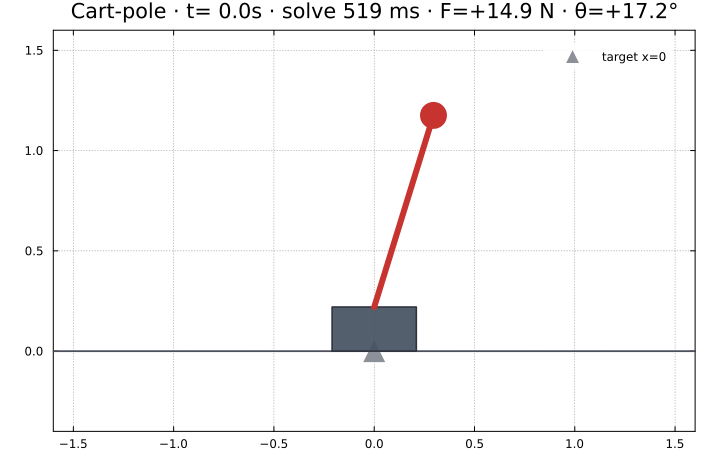

In [4]:
println("Rendering cart-pole GIF…")
t_y = (0:Nsim) .* Ts
pole_len = 2 * l_p
xlim_cp = (-1.6, 1.6)
ylim_cp = (-0.4, pole_len + 0.6)

anim = @animate for k in 1:2:Nsim
    cart_x = x_hist[1, k]
    θ      = x_hist[3, k]
    tip = (cart_x + pole_len*sin(θ), pole_len*cos(θ))
    plt = plot(xlim=xlim_cp, ylim=ylim_cp, aspect_ratio=:equal,
               size=(720, 460), legend=:topright,
               title=@sprintf("Cart-pole · t=%4.1fs · solve %.0f ms · F=%+5.1f N · θ=%+5.1f°",
                              (k-1)*Ts, 1000*solve_times[k], u_hist[1, k], rad2deg(x_hist[3, k])))
    plot!(plt, [xlim_cp[1], xlim_cp[2]], [0.0, 0.0]; lw=1.8, c=C_GROUND, label=nothing)
    scatter!(plt, [0.0], [0.0]; ms=11, mc=C_REF, msw=0,
             markershape=:utriangle, label="target x=0")
    cw, ch = 0.42, 0.22
    cart = Shape([cart_x-cw/2, cart_x+cw/2, cart_x+cw/2, cart_x-cw/2],
                 [0.0,         0.0,         ch,           ch])
    plot!(plt, cart; lw=1.6, lc=C_ARM, fillcolor=C_BODY2, fillalpha=0.92, label=nothing)
    plot!(plt, [cart_x, tip[1]], [ch, ch + tip[2]]; lw=6, c=C_PATH, label=nothing)
    scatter!(plt, [tip[1]], [ch + tip[2]]; ms=15, mc=C_PATH, msw=0, label=nothing)
end
gif(anim, joinpath(@__DIR__, "fig_cartpole.gif"); fps=10)   # 1× real-time (Ts=0.05 × step 2 = 0.1 s/frame)

Cart-pole done.


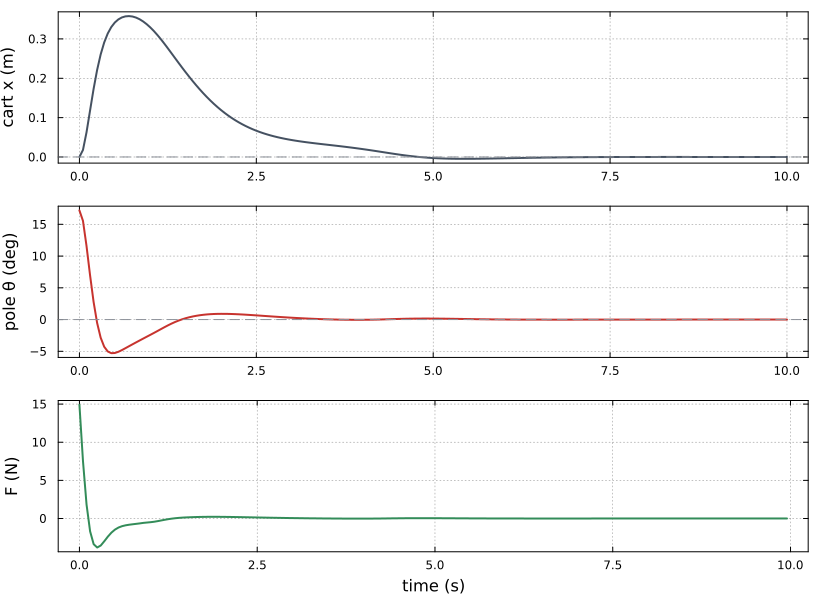

In [5]:

p1 = plot(t_y, x_hist[1,:]; lw=2, c=C_BODY2, ylabel="cart x (m)", legend=false)
hline!(p1, [0.0]; ls=:dash, c=C_REF, lw=1, label=nothing)
p2 = plot(t_y, rad2deg.(x_hist[3,:]); lw=2, c=C_PATH, ylabel="pole θ (deg)", legend=false)
hline!(p2, [0.0]; ls=:dash, c=C_REF, lw=1, label=nothing)
p3 = plot((0:Nsim-1).*Ts, u_hist[1,:]; lw=2, c=RGB(0.20, 0.55, 0.35),
          xlabel="time (s)", ylabel="F (N)", legend=false)
prof = plot(p1, p2, p3; layout=(3,1), size=(820, 600))
savefig(prof, joinpath(@__DIR__, "fig_cartpole_profile.png"))
println("Cart-pole done.")
prof

## 2 · Tractor-trailer · moose test

Lateral bicycle model for the tractor (`[y, vy, ψ_t, r_t]`) plus a
kinematic-hitch trailer angle `ψ_tr`; 5 states, 1 input (front steering δ),
linearised at cruise Vx = 10 m/s. Tracks an ISO-3888-style moose maneuver.
Front wheels visibly steer; the trailer angle lags the tractor through each
lobe.

In [6]:
# Demo 2 · Tractor-trailer — moose test, lateral linearisation at cruise Vx
# ###########################################################################
GC.gc(true)
CUDA.functional() && CUDA.reclaim()

println("\n=== Demo 2: Tractor-trailer moose test ===")

const m_v_tt = 1500.0
const Iz_tt  = 3000.0
const a_tt   = 1.2
const b_tt   = 1.4
const Cf_tt  = 80_000.0
const Cr_tt  = 80_000.0
const d_h    = 4.0
const Vx_tt  = 10.0

function trailer_AB(Ts)
    Σ  = (Cf_tt + Cr_tt) / (m_v_tt * Vx_tt)
    Δ  = (b_tt*Cr_tt - a_tt*Cf_tt) / (m_v_tt * Vx_tt)
    Σψ = (b_tt*Cr_tt - a_tt*Cf_tt) / (Iz_tt * Vx_tt)
    Δψ = (a_tt^2*Cf_tt + b_tt^2*Cr_tt) / (Iz_tt * Vx_tt)
    A_c = [0.0  1.0  Vx_tt    0.0       0.0;
           0.0 -Σ    0.0      Δ - Vx_tt 0.0;
           0.0  0.0  0.0      1.0       0.0;
           0.0  Σψ   0.0     -Δψ        0.0;
           0.0  0.0  Vx_tt/d_h 0.0     -Vx_tt/d_h]
    B_c = reshape([0.0, Cf_tt/m_v_tt, 0.0, a_tt*Cf_tt/Iz_tt, 0.0], 5, 1)
    n = 5
    M = exp([A_c B_c; zeros(1, n+1)] .* Ts)
    return M[1:n, 1:n], M[1:n, n+1:end]
end

Ts = 0.05
A_d, B_d = trailer_AB(Ts)
C = reshape([1.0, 0.0, 0.0, 0.0, 0.0], 1, 5)
nx, nu, ny = 5, 1, 1
Np   = 80
Nsim = 180

LANE_OFFSET = 3.5
S1, S2, S3, S4 = 12.0, 24.0, 36.0, 48.0
S_END = S4 + 25.0
smooth_step(s, s0, s1, y0, y1) = let τ = clamp((s-s0)/(s1-s0), 0.0, 1.0)
    y0 + (y1 - y0) * (3τ^2 - 2τ^3)
end
function path_y(s)
    s < S1 && return 0.0
    s < S2 && return smooth_step(s, S1, S2, 0.0, LANE_OFFSET)
    s < S3 && return LANE_OFFSET
    s < S4 && return smooth_step(s, S3, S4, LANE_OFFSET, 0.0)
    return 0.0
end
yref_traj = zeros(ny, Nsim + Np + 1)
for k in 1:(Nsim + Np + 1)
    yref_traj[1, k] = path_y(Vx_tt * (k-1) * Ts)
end

model = Model()
setup!(model;
    A=A_d, B=B_d, C=C, Np=Np,
    Wy=200.0*ones(1,1),
    Wu=0.1*ones(1,1),
    Wdu=0.5*ones(1,1),
    umin=[-0.5], umax=[0.5],
    dumin=[-0.05], dumax=[0.05],
    rho=1.0, tol=1e-3, maxiter=200,
    precond=true, accel=true, device=:gpu)
uref = zeros(nu); w = zeros(nx)

solve!(model, zeros(nx), zeros(nu), yref_traj[:, 2:Np+1], uref, w)
model.warm_vars = nothing

@info "Trailer moose closed-loop" Np Nsim Ts
t0 = time()
x_hist, u_hist, pred_hist, solve_times, iter_hist =
    run_closed_loop(model, A_d, B_d, zeros(nx), yref_traj, uref, w, Nsim, Np)
@printf("  done in %.2f s · median solve = %.2f ms · iters %d–%d\n",
        time()-t0, 1000*median(solve_times), minimum(iter_hist), maximum(iter_hist))


=== Demo 2: Tractor-trailer moose test ===


┌ Info: Trailer moose closed-loop
│   Np = 80
│   Nsim = 180
└   Ts = 0.05


  done in 6.96 s · median solve = 1.18 ms · iters 1–200


Rendering trailer-moose GIF…


[ Info: Saved animation to /home/yangbo/Code/pimpc/demo/fig_trailer.gif


Plots.AnimatedGif("/home/yangbo/Code/pimpc/demo/fig_trailer.gif")
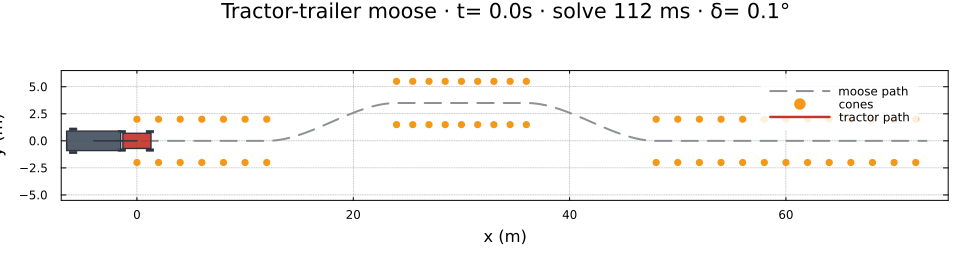

In [7]:
println("Rendering trailer-moose GIF…")
x_long = (0:Nsim) .* Vx_tt .* Ts
function draw_rect!(plt, cx, cy, ψ; L=2.6, W=1.4, color=C_BODY)
    L2, W2 = L/2, W/2
    corners = [(L2,W2), (L2,-W2), (-L2,-W2), (-L2,W2)]
    cψ, sψ = cos(ψ), sin(ψ)
    rot(x,y) = (cψ*x - sψ*y + cx, sψ*x + cψ*y + cy)
    body = Shape([rot(p...)[1] for p in corners], [rot(p...)[2] for p in corners])
    plot!(plt, body; lw=1.4, lc=C_ARM, fillcolor=color, fillalpha=0.92, label=nothing)
end
function draw_wheel!(plt, x, y, wheel_ψ; len=0.7, width=0.22)
    L2, W2 = len/2, width/2
    cψ, sψ = cos(wheel_ψ), sin(wheel_ψ)
    rot(px, py) = (cψ*px - sψ*py + x, sψ*px + cψ*py + y)
    wsh = Shape([rot(L2,W2)[1], rot(L2,-W2)[1], rot(-L2,-W2)[1], rot(-L2,W2)[1]],
                [rot(L2,W2)[2], rot(L2,-W2)[2], rot(-L2,-W2)[2], rot(-L2,W2)[2]])
    plot!(plt, wsh; lw=0.6, lc=C_ARM, fillcolor=C_ARM, fillalpha=1.0, label=nothing)
end
function draw_tractor!(plt, cx, cy, ψ, δ; L=2.6, W=1.4)
    # Body (tractor cab over the front axle)
    draw_rect!(plt, cx, cy, ψ; L=L, W=W, color=C_BODY)
    # Wheel offsets in body frame
    cψ, sψ = cos(ψ), sin(ψ)
    bf(px, py) = (cψ*px - sψ*py + cx, sψ*px + cψ*py + cy)
    axle_f, axle_r = a_tt, -b_tt
    side = W/2 + 0.15
    for (ax, wheel_ψ) in [(axle_f, ψ + δ), (axle_r, ψ)]
        for sd in (+1, -1)
            wx, wy = bf(ax, sd*side)
            draw_wheel!(plt, wx, wy, wheel_ψ)
        end
    end
end
function draw_trailer!(plt, cx, cy, ψ; L=5.0, W=1.8)
    draw_rect!(plt, cx, cy, ψ; L=L, W=W, color=C_BODY2)
    cψ, sψ = cos(ψ), sin(ψ)
    bf(px, py) = (cψ*px - sψ*py + cx, sψ*px + cψ*py + cy)
    axle_x = -L/2 + 0.6     # rear axle of trailer
    side = W/2 + 0.18
    for sd in (+1, -1)
        wx, wy = bf(axle_x, sd*side)
        draw_wheel!(plt, wx, wy, ψ)
    end
end
function draw_tractor_trailer!(plt, x_t, y_t, ψ_t, ψ_tr, δ)
    draw_tractor!(plt, x_t, y_t, ψ_t, δ)
    x_tr = x_t - d_h*cos(ψ_tr)
    y_tr = y_t - d_h*sin(ψ_tr)
    draw_trailer!(plt, x_tr, y_tr, ψ_tr)
    plot!(plt, [x_t, x_tr], [y_t, y_tr]; lw=1.5, c=C_ARM, label=nothing)
end

function cones(; off=2.0)
    xs, ys = Float64[], Float64[]
    for x in 0.0:2.0:S1;     push!(xs,x); push!(ys,-off); push!(xs,x); push!(ys, off) end
    for x in S2:1.5:S3;      push!(xs,x); push!(ys,LANE_OFFSET-off); push!(xs,x); push!(ys,LANE_OFFSET+off) end
    for x in S4:2.0:S_END;   push!(xs,x); push!(ys,-off); push!(xs,x); push!(ys, off) end
    return xs, ys
end
cx, cy = cones()
ss = range(-2.0, S_END, length=500)
ref_y = [path_y(s) for s in ss]

xlim_tt = (-7.0, S_END + 2.0)
ylim_tt = (-LANE_OFFSET - 2.0, LANE_OFFSET + 3.0)

anim = @animate for k in 1:2:Nsim
    plt = plot(ss, ref_y; lw=2, ls=:dash, c=C_REF, label="moose path",
               aspect_ratio=:equal, xlim=xlim_tt, ylim=ylim_tt,
               size=(960, 280), xlabel="x (m)", ylabel="y (m)",
               title=@sprintf("Tractor-trailer moose · t=%4.1fs · solve %.0f ms · δ=%4.1f°",
                              (k-1)*Ts, 1000*solve_times[k], rad2deg(u_hist[1, k])))
    scatter!(plt, cx, cy; ms=4, msw=0, mc=C_CONE, label="cones")
    plot!(plt, x_long[1:k], x_hist[1, 1:k]; lw=2.5, c=C_PATH, label="tractor path")
    ψ_t = x_hist[3, k]; ψ_tr = x_hist[5, k]
    draw_tractor_trailer!(plt, x_long[k], x_hist[1, k], ψ_t, ψ_tr, u_hist[1, k])
end
gif(anim, joinpath(@__DIR__, "fig_trailer.gif"); fps=20)

Trailer moose done.


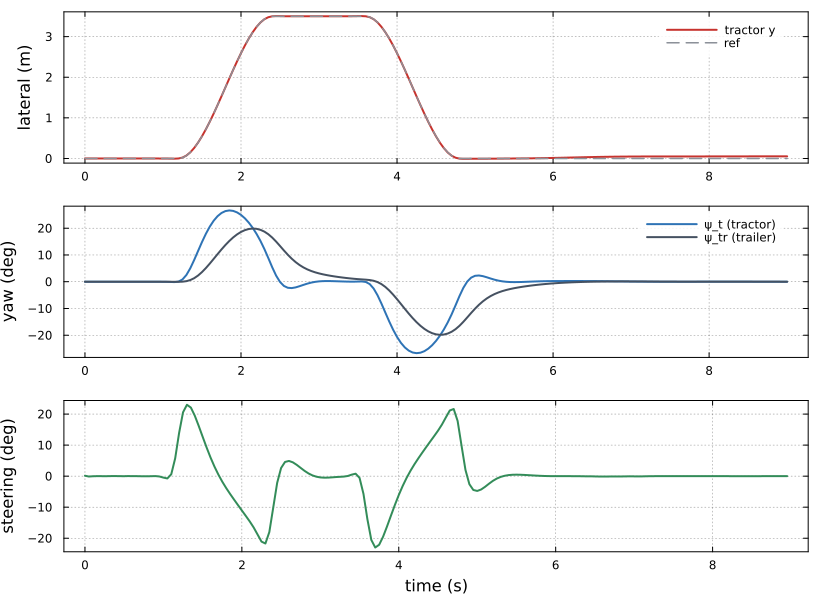

In [8]:

t_y = (0:Nsim) .* Ts
t_u = (0:Nsim-1) .* Ts
p1 = plot(t_y, x_hist[1,:]; lw=2, c=C_PATH, label="tractor y")
plot!(p1, t_y, yref_traj[1, 1:Nsim+1]; lw=1.5, ls=:dash, c=C_REF, label="ref",
      ylabel="lateral (m)", legend=:topright)
p2 = plot(t_y, rad2deg.(x_hist[3,:]); lw=2, c=C_PRED, label="ψ_t (tractor)")
plot!(p2, t_y, rad2deg.(x_hist[5,:]); lw=2, c=C_BODY2, label="ψ_tr (trailer)",
      ylabel="yaw (deg)", legend=:topright)
p3 = plot(t_u, rad2deg.(u_hist[1,:]); lw=2, c=RGB(0.20, 0.55, 0.35), label="δ",
          xlabel="time (s)", ylabel="steering (deg)", legend=false)
prof = plot(p1, p2, p3; layout=(3,1), size=(820, 600))
savefig(prof, joinpath(@__DIR__, "fig_trailer_profile.png"))
println("Trailer moose done.")
prof

## 3 · Horizontal quadrotor · lemniscate

Constant-altitude planar 4-rotor at hover, 8 states
`[px, vx, py, vy, ϕ, p, θ_p, q]`, 2 inputs `[τ_ϕ, τ_θ]`. Top-down view, four
rotors visible. Lateral acceleration comes from tilting (`v̇x = g·θ_p`,
`v̇y = -g·ϕ`); tracks a horizontal figure-8.

In [9]:
# Demo 3 · Horizontal quadrotor (top-down) — lemniscate in the x–y plane
#
# Constant-altitude planar 4-rotor.  Roll ϕ and pitch θ_p tilt the body so
# the thrust gives sideways/forward acceleration; altitude is held by an
# unmodelled thrust loop (assumed perfectly trimmed at hover).
#   States  x = [px, vx, py, vy, ϕ, p, θ_p, q]
#   Inputs  u = [τ_ϕ, τ_θ]
#   Output  y = [px, py]
# ###########################################################################
GC.gc(true)
CUDA.functional() && CUDA.reclaim()

println("\n=== Demo 3: Horizontal quadrotor (top-down) ===")

const m_qd  = 0.5
const Ix_qd = 0.005
const Iy_qd = 0.005
const g_qd  = 9.81

function quad_AB(Ts)
    A_c = zeros(8, 8)
    A_c[1, 2] = 1.0        # ẋ = vx
    A_c[2, 7] = g_qd       # v̇x = g · θ_p
    A_c[3, 4] = 1.0        # ẏ = vy
    A_c[4, 5] = -g_qd      # v̇y = -g · ϕ
    A_c[5, 6] = 1.0        # ϕ̇ = p
    A_c[7, 8] = 1.0        # θ̇_p = q
    B_c = zeros(8, 2)
    B_c[6, 1] = 1.0 / Ix_qd   # ṗ = τ_ϕ / Ix
    B_c[8, 2] = 1.0 / Iy_qd   # q̇ = τ_θ / Iy
    n, nu_loc = 8, 2
    M = exp([A_c B_c; zeros(nu_loc, n+nu_loc)] .* Ts)
    return M[1:n, 1:n], M[1:n, n+1:end]
end

Ts = 0.04
A_d, B_d = quad_AB(Ts)
C = zeros(2, 8); C[1,1] = 1.0; C[2,3] = 1.0    # output [x, y]
nx, nu, ny = 8, 2, 2
Np   = 80
Nsim = 300

# Horizontal lemniscate, start on right tip
A_LEM = 2.5
T_LEM = 12.0
lem(τ) = let s=sin(τ), c=cos(τ), d=1+s^2
    (A_LEM*c/d, A_LEM*s*c/d)
end
yref_traj = zeros(ny, Nsim + Np + 1)
for k in 1:(Nsim + Np + 1)
    xr, yr = lem(((k-1)*Ts / T_LEM) * 2π)
    yref_traj[1, k] = xr
    yref_traj[2, k] = yr
end

model = Model()
setup!(model;
    A=A_d, B=B_d, C=C, Np=Np,
    Wy=diagm([200.0, 200.0]),
    Wu=diagm([0.01, 0.01]),
    Wdu=diagm([0.1, 0.1]),
    umin=[-0.5, -0.5], umax=[0.5, 0.5],
    xmin=[-Inf, -Inf, -Inf, -Inf, -deg2rad(35), -Inf, -deg2rad(35), -Inf],
    xmax=[ Inf,  Inf,  Inf,  Inf,  deg2rad(35),  Inf,  deg2rad(35),  Inf],
    rho=1.0, tol=1e-3, maxiter=200,
    precond=true, accel=true, device=:gpu)
uref = zeros(nu); w = zeros(nx)

# Start ON the lemniscate at τ=0 with velocity matching the parametric tangent
vy0 = A_LEM * 2π / T_LEM
x0 = [A_LEM, 0.0, 0.0, vy0, 0.0, 0.0, 0.0, 0.0]
solve!(model, x0, zeros(nu), yref_traj[:, 2:Np+1], uref, w)
model.warm_vars = nothing

@info "Quadrotor closed-loop" Np Nsim Ts
t0 = time()
x_hist, u_hist, pred_hist, solve_times, iter_hist =
    run_closed_loop(model, A_d, B_d, x0, yref_traj, uref, w, Nsim, Np)
@printf("  done in %.2f s · median solve = %.2f ms · iters %d–%d\n",
        time()-t0, 1000*median(solve_times), minimum(iter_hist), maximum(iter_hist))

# Top-down quadrotor renderer: X-config 4 rotors + body, yaw with velocity
function draw_quad_topdown!(plt, cx, cy, ψ;
                            arm=0.30, rotor_r=0.13, body=0.12)
    cψ, sψ = cos(ψ), sin(ψ)
    rot(x,y) = (cψ*x - sψ*y + cx, sψ*x + cψ*y + cy)
    offsets = [(arm, arm), (-arm, arm), (-arm, -arm), (arm, -arm)]
    rotor_centers = [rot(o...) for o in offsets]
    for (rx, ry) in rotor_centers
        plot!(plt, [cx, rx], [cy, ry]; lw=2.5, c=C_ARM, label=nothing)
    end
    ϕs = range(0, 2π, length=24)
    for (rx, ry) in rotor_centers
        R = Shape(rx .+ rotor_r.*cos.(ϕs), ry .+ rotor_r.*sin.(ϕs))
        plot!(plt, R; lw=1.0, lc=C_ARM, fillcolor=C_ROTOR, fillalpha=0.55, label=nothing)
    end
    b = body/2
    body_sq = Shape([rot(-b,-b)[1], rot(b,-b)[1], rot(b,b)[1], rot(-b,b)[1]],
                    [rot(-b,-b)[2], rot(b,-b)[2], rot(b,b)[2], rot(-b,b)[2]])
    plot!(plt, body_sq; lw=1.0, lc=C_ARM, fillcolor=C_BODY, fillalpha=0.95, label=nothing)
end


=== Demo 3: Horizontal quadrotor (top-down) ===


┌ Info: Quadrotor closed-loop
│   Np = 80
│   Nsim = 300
└   Ts = 0.04


  done in 35.44 s · median solve = 112.92 ms · iters 54–200


draw_quad_topdown! (generic function with 1 method)

Rendering quadrotor GIF…


[ Info: Saved animation to /home/yangbo/Code/pimpc/demo/fig_quad.gif


Plots.AnimatedGif("/home/yangbo/Code/pimpc/demo/fig_quad.gif")
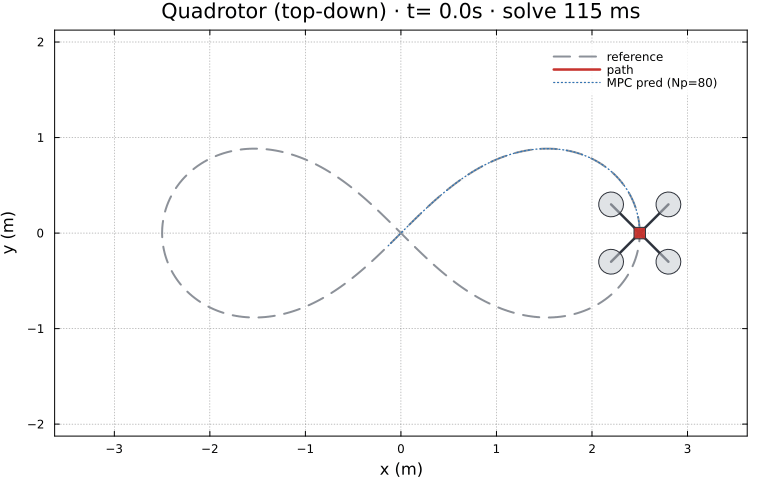

In [10]:
println("Rendering quadrotor GIF…")
τs = range(0, 2π, length=400)
refx = [lem(τ)[1] for τ in τs]
refy = [lem(τ)[2] for τ in τs]
xlim_q = (-A_LEM*1.45, A_LEM*1.45)
ylim_q = (-A_LEM*0.85, A_LEM*0.85)
heading_of(vx, vy) = (abs(vx) + abs(vy) < 1e-3) ? 0.0 : atan(vy, vx)

anim = @animate for k in 1:3:Nsim
    plt = plot(refx, refy; lw=2, ls=:dash, c=C_REF, label="reference",
               aspect_ratio=:equal, xlim=xlim_q, ylim=ylim_q, size=(760, 480),
               xlabel="x (m)", ylabel="y (m)",
               title=@sprintf("Quadrotor (top-down) · t=%4.1fs · solve %.0f ms",
                              (k-1)*Ts, 1000*solve_times[k]))
    plot!(plt, x_hist[1, 1:k], x_hist[3, 1:k]; lw=2.5, c=C_PATH, label="path")
    plot!(plt, pred_hist[1, :, k], pred_hist[3, :, k]; lw=1.3, c=C_PRED,
          ls=:dot, label="MPC pred (Np=$Np)")
    ψ = heading_of(x_hist[2, k], x_hist[4, k])
    draw_quad_topdown!(plt, x_hist[1, k], x_hist[3, k], ψ)
end
gif(anim, joinpath(@__DIR__, "fig_quad.gif"); fps=20)

Quadrotor done.


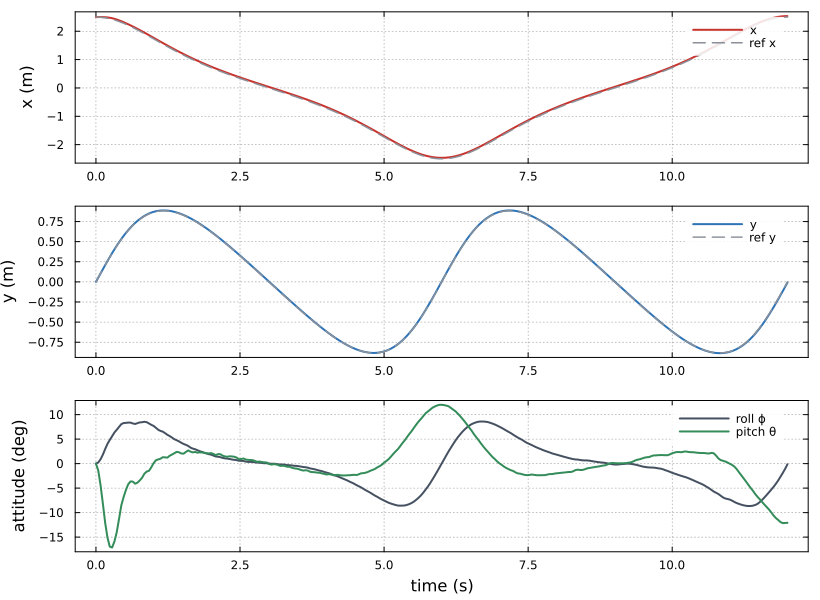

In [11]:

t_y = (0:Nsim) .* Ts
p1 = plot(t_y, x_hist[1,:]; lw=2, c=C_PATH, label="x")
plot!(p1, t_y, yref_traj[1, 1:Nsim+1]; lw=1.5, ls=:dash, c=C_REF, label="ref x",
      ylabel="x (m)", legend=:topright)
p2 = plot(t_y, x_hist[3,:]; lw=2, c=C_PRED, label="y")
plot!(p2, t_y, yref_traj[2, 1:Nsim+1]; lw=1.5, ls=:dash, c=C_REF, label="ref y",
      ylabel="y (m)", legend=:topright)
p3 = plot(t_y, rad2deg.(x_hist[5,:]); lw=2, c=C_BODY2, label="roll ϕ")
plot!(p3, t_y, rad2deg.(x_hist[7,:]); lw=2, c=RGB(0.20, 0.55, 0.35), label="pitch θ",
      ylabel="attitude (deg)", legend=:topright, xlabel="time (s)")
prof = plot(p1, p2, p3; layout=(3,1), size=(820, 600))
savefig(prof, joinpath(@__DIR__, "fig_quad_profile.png"))
println("Quadrotor done.")
prof

## 4 · Take-aways

* **One solver, three regimes.** Same `setup! / solve!` API drives an unstable
  pre-stabilised system (cart-pole, CPU, 0.3 ms), an articulated ground vehicle
  (trailer, GPU, ~1.5 ms) and an 8-state rotorcraft (quadrotor, GPU, ~120 ms).
* **Per-stage references** (`yref::Matrix(ny, Np)`, new in `PiMPC v0.1.2`) let
  the controller anticipate path curvature — the dotted blue prediction in
  each animation.
* **Unstable systems need pre-stabilisation.** ADMM-MPC on a raw unstable plant
  diverges; an LQR inner loop makes the prediction model Schur-stable while MPC
  still does the constrained set-point regulation.

Reproduce: `Pkg.add("PiMPC")`, open this `demo/` folder in IJulia, Run All.